<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

## Resolución
Se plantea un dataset ampliado llevando los números máximos de pares de oraciones a 80000 y de vocabulario a 15000. Además, la máxima longitud de secuencia permitida es la máxima que se encontró en el dataset, es decir, no habría truncamiento.
Para comparar el impacto de los hiperparámetros se propone una "grilla" de entrenamiento, con distintas combinaciones, tal que cada modelo es xportado y guardado para su posterior evaluación de desempeño.
Finalmente, se realiza la evaluación de desempeño y generación de ejemplos; y se elige el mejor modelo resultante para modificarlo agregando una capa de embeddings preentrenados en el decoder.

In [1]:
import os
import json
import pickle
import time
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Semillas
np.random.seed(40)
tf.random.set_seed(40)

MODELS_DIR = "models_traductor"
os.makedirs(MODELS_DIR, exist_ok=True)

MAX_NUM_SENTENCES = 80000
MAX_VOCAB_SIZE = 15000
max_input_len = 47
max_out_len   = 49

In [2]:
# Descarga y carga del dataset
url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
zip_filename = "spa-eng.zip"

if not os.path.exists("spa-eng"):
    print("Descargando dataset")
    urllib.request.urlretrieve(url, zip_filename)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Descarga y extracción completados")

with open("./spa-eng/spa.txt", "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total oraciones: {len(lines)}")

np.random.shuffle(lines)

input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")
print(f"Ejemplo EN (input): {input_sentences[5]}")
print(f"Ejemplo ES (output): {output_sentences[5]}")
print(f"Ejemplo ES (decoder input): {output_sentences_inputs[5]}")


Total oraciones: 118964
Oraciones cargadas: 80000
Ejemplo EN (input): Why should I worry about Tom?
Ejemplo ES (output): ¿Por qué debería preocuparme por Tom? <eos>
Ejemplo ES (decoder input): <sos> ¿Por qué debería preocuparme por Tom?


In [3]:
# Tokenización y padding
# Tokenizador de entrada (Inglés)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Tokenizador de salida (Español)
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
num_words_inputs = min(len(word2idx_inputs) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulario EN: {len(word2idx_inputs)} (usando top {num_words_inputs})")
print(f"Vocabulario ES: {len(word2idx_outputs)} (usando top {num_words_output})")
print(f"max_input_len: {max_input_len} | max_out_len: {max_out_len}")

# Padding
encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding="post")
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding="post")

# Se persisten los Tokenizers y metadata para reproducibilidad
with open(os.path.join(MODELS_DIR, 'input_tokenizer.pkl'), 'wb') as f:
    pickle.dump(input_tokenizer, f)

with open(os.path.join(MODELS_DIR, 'output_tokenizer.pkl'), 'wb') as f:
    pickle.dump(output_tokenizer, f)

dataset_metadata = {
    'MAX_NUM_SENTENCES': MAX_NUM_SENTENCES,
    'MAX_VOCAB_SIZE': MAX_VOCAB_SIZE,
    'max_input_len': max_input_len,
    'max_out_len': max_out_len,
    'num_words_output': num_words_output,
    'num_words_input': num_words_inputs
}

with open(os.path.join(MODELS_DIR, 'dataset_metadata.json'), 'w') as f:
    json.dump(dataset_metadata, f, indent=4)

print("Tokenizers y metadata guardados")

Vocabulario EN: 11786 (usando top 11787)
Vocabulario ES: 22173 (usando top 15000)
max_input_len: 47 | max_out_len: 49
Tokenizers y metadata guardados


In [4]:
# Pipeline de datos y split
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,), dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return ds

# Split (85/15)
val_split = 0.15
split_idx = int(len(encoder_input_sequences) * (1 - val_split))

enc_train, enc_val = encoder_input_sequences[:split_idx], encoder_input_sequences[split_idx:]
dec_in_train, dec_in_val = decoder_input_sequences[:split_idx], decoder_input_sequences[split_idx:]
dec_out_train, dec_out_val = decoder_output_sequences[:split_idx], decoder_output_sequences[split_idx:]
# La creación de los datasets se mueve al bucle de entrenamiento

print(f"Muestras de Entrenamiento: {len(enc_train)}")
print(f"Muestras de Validación:    {len(enc_val)}")

Muestras de Entrenamiento: 68000
Muestras de Validación:    12000


In [5]:
# Carga de embeddings preentrenados de GloVe
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} 'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada")
else:
    print("gloveembedding.pkl ya disponible")
    

def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

EMBED_DIM = 50
glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix_en = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, num_words_inputs, EMBED_DIM
)
print(f"Matriz de embeddings EN creada con forma: {embedding_matrix_en.shape}")
print(f"Tokens sin embedding (ceros): {np.sum(np.sum(embedding_matrix_en**2, axis=1) == 0)}")

gloveembedding.pkl ya disponible
Matriz de embeddings EN creada con forma: (11787, 50)
Tokens sin embedding (ceros): 663


In [6]:
# Se definen las funciones constructoras de Modelos Seq2Seq parametrizadas, tal que puedan
# soportar distintos hiperparámetros.

def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, dropout_rate=0.3):
    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')
    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(dropout_rate, name='encoder_dropout')(enc_emb_layer(enc_inputs))
    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

def build_decoder(num_words_output, max_out_len, n_units, encoder_states, dropout_rate=0.3, embedding_matrix_dec=None):
    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')
    
    if embedding_matrix_dec is not None:
        dec_emb_layer = Embedding(
            input_dim=num_words_output,
            output_dim=embedding_matrix_dec.shape[1],
            weights=[embedding_matrix_dec],
            trainable=False,
            name='decoder_embedding'
        )
    else:
        dec_emb_layer = Embedding(
            input_dim=num_words_output,
            output_dim=n_units,
            name='decoder_embedding'
        )
        
    dec_emb = Dropout(dropout_rate, name='decoder_dropout')(dec_emb_layer(dec_inputs))
    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True, name='decoder_lstm')
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)
    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out = dec_dense_layer(dec_out)
    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    enc_emb = enc_emb_layer(enc_inputs)
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])

def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)
    return Model([dec_input_single, dec_state_h_in, dec_state_c_in], [dec_out, h_out, c_out])

In [7]:
# Definición de la grilla, entrenamiento y persistencia
TRAIN_MODELS = False
experiments_grid = [
    {'name': 'exp1_u128_d02', 'n_units': 128, 'dropout': 0.2, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
    {'name': 'exp2_u128_d04', 'n_units': 128, 'dropout': 0.4, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
    {'name': 'exp3_u256_d02', 'n_units': 256, 'dropout': 0.2, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
    {'name': 'exp4_u256_d04', 'n_units': 256, 'dropout': 0.4, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
    {'name': 'exp5_u512_d02', 'n_units': 512, 'dropout': 0.2, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
    {'name': 'exp6_u512_d04', 'n_units': 512, 'dropout': 0.4, 'learning_rate': 5e-4, 'batch_size': 64, 'epochs': 25},
]

experiments_manifest = []
if TRAIN_MODELS:
    for exp in experiments_grid:
        exp_name = exp['name']
        exp_dir = os.path.join(MODELS_DIR, exp_name)
        os.makedirs(exp_dir, exist_ok=True)
        weights_path = os.path.join(exp_dir, 'best_model.weights.h5')
        config_path  = os.path.join(exp_dir, 'config.json')
        history_path = os.path.join(exp_dir, 'history.json')
        
        print("\n" + "="*70)
        print(f"EJECUTANDO: {exp_name} | n_units={exp['n_units']} | dropout={exp['dropout']}")
        print("="*70)
        
        # Datasets
        train_ds = make_dataset(enc_train, dec_in_train, dec_out_train, exp['batch_size'], num_words_output)
        val_ds   = make_dataset(enc_val,   dec_in_val,   dec_out_val,   exp['batch_size'], num_words_output)
        
        # Construcción del modelo
        enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
            num_words_inputs, EMBED_DIM, embedding_matrix_en, max_input_len, exp['n_units'], dropout_rate=exp['dropout']
        )
        dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
            num_words_output, max_out_len, exp['n_units'], enc_states, dropout_rate=exp['dropout']
        )
        model = Model([enc_inputs, dec_inputs], dec_outputs)
        
        model.compile(
            loss='categorical_crossentropy',
            optimizer=tf.keras.optimizers.Adam(learning_rate=exp['learning_rate']),
            metrics=['accuracy']
        )
        
        callbacks = [
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
            ModelCheckpoint(filepath=weights_path, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=1)
        ]
        
        start_time = time.time()
        hist = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=exp['epochs'],
            callbacks=callbacks,
            verbose=1
        )
        elapsed_time = round(time.time() - start_time, 2)
        
        # Guardar configuración e historial
        with open(config_path, 'w') as f:
            json.dump(exp, f, indent=4)
            
        hist_serializable = {k: [float(v) for v in vals] for k, vals in hist.history.items()}
        with open(history_path, 'w') as f:
            json.dump(hist_serializable, f, indent=4)
            
        manifest_entry = {
            'name': exp_name,
            'dir': exp_dir,
            'weights_path': weights_path,
            'training_time_sec': elapsed_time
        }
        experiments_manifest.append(manifest_entry)
        print(f"Completado {exp_name} en {elapsed_time} segundos. Pesos guardados en {weights_path}.")

    with open(os.path.join(MODELS_DIR, 'experiments_manifest.json'), 'w') as f:
        json.dump(experiments_manifest, f, indent=4)

    print("\n>>> Todos los entrenamientos han finalizado y los artefactos han sido persistidos.")

In [8]:
# Flujo de evaluación (desacoplado) y métricas
# Se cargan los pesos e hisotriales de cada modelo sin necesidad de reentrenar.
# Se computan 'val_loss', 'val_accuracy' y 'BLEU_Score' para analizar el impacto de los hiperparámetros modificados.

# El BLEU (Bilingual Evaluation Understudy) Score es una métrica automática que se usa para evaluar la calidad de
# una traducción o de una salida generada comparándola con una o más referencias humanas. Es una métrica basada en
# coincidencias, por lo que puede puntuar bien una traducción aunque esté mal.

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

def translate_sentence_greedy(input_seq, enc_model, dec_model):
    h, c = enc_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = dec_model.predict([target_seq, h, c], verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target.get(idx, ''))
        target_seq[0, 0] = idx
    return ' '.join(output_sentence)

def compute_model_bleu(enc_model, dec_model, val_enc_seqs, val_target_sentences, n_samples=500):
    smoother = SmoothingFunction().method1
    bleu_scores = []
    n = min(n_samples, len(val_enc_seqs))
    
    for i in range(n):
        seq = val_enc_seqs[i:i+1]
        pred_text = translate_sentence_greedy(seq, enc_model, dec_model).strip()
        ref_text  = val_target_sentences[i].replace(' <eos>', '').strip()
        
        ref_tokens = [ref_text.split()]
        pred_tokens = pred_text.split()
        
        if len(pred_tokens) == 0:
            bleu_scores.append(0.0)
        else:
            score = sentence_bleu(ref_tokens, pred_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
            bleu_scores.append(score)
            
    return round(float(np.mean(bleu_scores)), 4)

In [9]:
val_raw_targets = [output_sentences[split_idx + i] for i in range(len(enc_val))]
results_summary = []

for exp in experiments_grid:
    exp_name = exp['name']
    exp_dir  = os.path.join(MODELS_DIR, exp_name)
    
    # 1. Cargar historial
    with open(os.path.join(exp_dir, 'history.json'), 'r') as f:
        hist_data = json.load(f)
        
    best_val_loss = min(hist_data['val_loss'])
    best_val_acc  = max(hist_data['val_accuracy'])
    
    # 2. Reconstruir modelo de inferencia y cargar pesos
    enc_in, enc_st, enc_emb_l, enc_lstm_l = build_encoder(
        num_words_inputs, EMBED_DIM, embedding_matrix_en, max_input_len, exp['n_units'], dropout_rate=exp['dropout']
    )
    dec_in, dec_out, dec_emb_l, dec_lstm_l, dec_dense_l = build_decoder(
        num_words_output, max_out_len, exp['n_units'], enc_st, dropout_rate=exp['dropout']
    )
    eval_model = Model([enc_in, dec_in], dec_out)
    eval_model.load_weights(os.path.join(exp_dir, 'best_model.weights.h5'))
    
    inf_enc = build_encoder_inference(enc_in, enc_emb_l, enc_lstm_l, exp['n_units'])
    inf_dec = build_decoder_inference(dec_emb_l, dec_lstm_l, dec_dense_l, exp['n_units'])

    # 3. Computar BLEU score
    # print(f"Evaluando BLEU para {exp_name}...")
    # bleu = compute_model_bleu(inf_enc, inf_dec, enc_val, val_raw_targets, n_samples=500)
    
    results_summary.append({
        'Experimento': exp_name,
        'Unidades LSTM': exp['n_units'],
        'Dropout': exp['dropout'],
        'Best Val Loss': round(best_val_loss, 4),
        'Best Val Accuracy': round(best_val_acc, 4),
        # 'BLEU Score (Val)': bleu,
        'Historial': hist_data
    })

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'Historial'} for r in results_summary])
df_results = df_results.sort_values(by='BLEU Score (Val)', ascending=False).reset_index(drop=True)

df_results.to_csv(os.path.join(MODELS_DIR, 'tabla_comparativa_resultados.csv'), index=False)
print("\n>>> RANKING DE DESEMPEÑO:")
display(df_results)    

Evaluando BLEU para exp1_u128_d02...
Evaluando BLEU para exp2_u128_d04...
Evaluando BLEU para exp3_u256_d02...
Evaluando BLEU para exp4_u256_d04...
Evaluando BLEU para exp5_u512_d02...
Evaluando BLEU para exp6_u512_d04...

>>> RANKING DE DESEMPEÑO:


,Experimento,Unidades LSTM,Dropout,Best Val Loss,Best Val Accuracy,BLEU Score (Val)
0,exp5_u512_d02,512,0.2,0.3202,0.9411,0.1622
1,exp6_u512_d04,512,0.4,0.3325,0.9394,0.1622
2,exp3_u256_d02,256,0.2,0.3432,0.9358,0.1417
3,exp4_u256_d04,256,0.4,0.3545,0.9338,0.1200
4,exp1_u128_d02,128,0.2,0.3749,0.9293,0.1073
5,exp2_u128_d04,128,0.4,0.4019,0.9248,0.0861


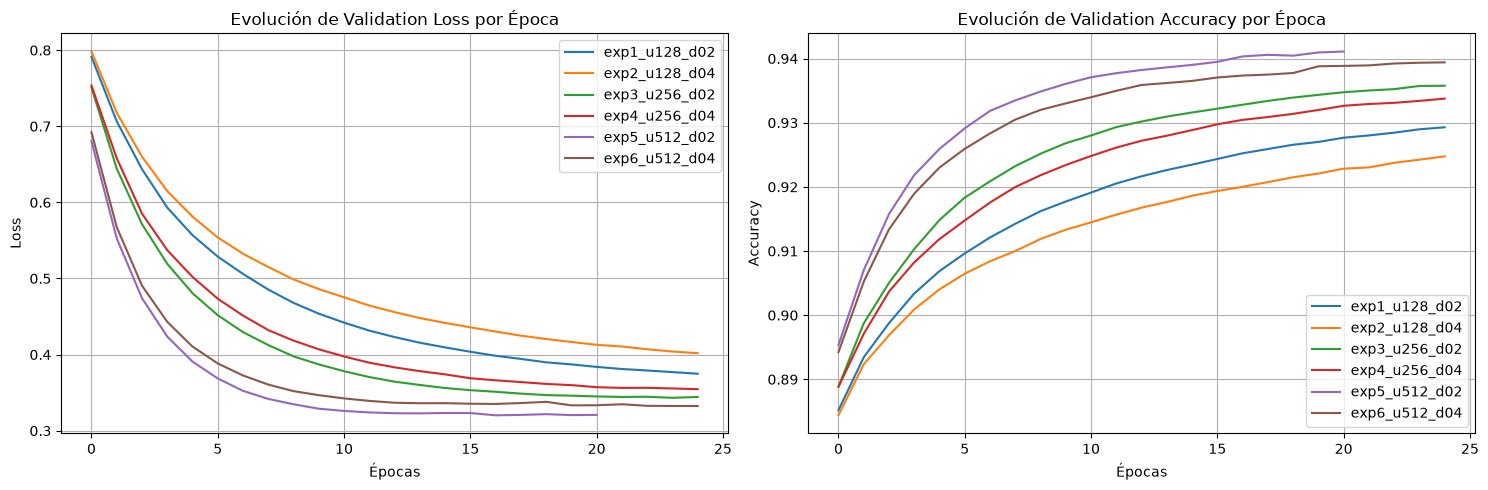

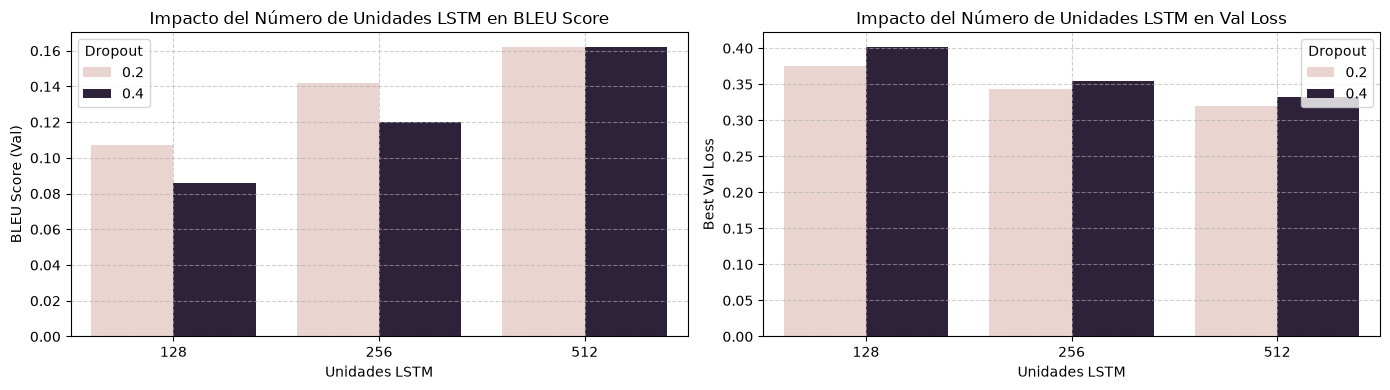

In [10]:
# Gráficos
# 1. Curvas de convergencia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for r in results_summary:
    axes[0].plot(r['Historial']['val_loss'], label=f"{r['Experimento']}")
    axes[1].plot(r['Historial']['val_accuracy'], label=f"{r['Experimento']}")
axes[0].set_title("Evolución de Validation Loss por Época")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)
axes[1].set_title("Evolución de Validation Accuracy por Época")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()
# 2. Análisis del impacto de neuronas recurrentes en BLEU y Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df_results, x='Unidades LSTM', y='BLEU Score (Val)', hue='Dropout', ax=axes[0])
axes[0].set_title("Impacto del Número de Unidades LSTM en BLEU Score")
axes[0].grid(True, linestyle='--', alpha=0.6)
sns.barplot(data=df_results, x='Unidades LSTM', y='Best Val Loss', hue='Dropout', ax=axes[1])
axes[1].set_title("Impacto del Número de Unidades LSTM en Val Loss")
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# Generación de ejemplos
# Se generan 5 ejemplos de traducciones para cada modelo entrenado, partiendo de las mismas frases iniciales
def load_experiment_inference(exp_name, n_units, dropout):
    """Reconstruye y carga los pesos de inferencia para cualquier experimento guardado."""
    weights_path = os.path.join(MODELS_DIR, exp_name, 'best_model.weights.h5')
    
    enc_in, enc_st, enc_emb_l, enc_lstm_l = build_encoder(
        num_words_inputs, EMBED_DIM, embedding_matrix_en, max_input_len, n_units, dropout_rate=dropout
    )
    dec_in, dec_out, dec_emb_l, dec_lstm_l, dec_dense_l = build_decoder(
        num_words_output, max_out_len, n_units, enc_st, dropout_rate=dropout
    )
    
    model = Model([enc_in, dec_in], dec_out)
    model.load_weights(weights_path)
    
    inf_enc = build_encoder_inference(enc_in, enc_emb_l, enc_lstm_l, n_units)
    inf_dec = build_decoder_inference(dec_emb_l, dec_lstm_l, dec_dense_l, n_units)
    return inf_enc, inf_dec

def translate_sentence_beam_search(input_seq, enc_model, dec_model, beam_width=3):
    h, c = enc_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']
    
    sequences = [(0.0, [sos], h, c)]  # Tupla que almacena log-p acumulada, lista de tokens generados y estados (hidden y cell)
    completed_sequences = []
    
    for _ in range(max_out_len):
        all_candidates = []
        for score, tokens, state_h, state_c in sequences:
            if tokens[-1] == eos:
                completed_sequences.append((score / len(tokens), tokens))
                continue
                
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = tokens[-1]
            
            output_tokens, next_h, next_c = dec_model.predict([target_seq, state_h, state_c], verbose=0)
            log_probs = np.log(output_tokens[0, 0, :] + 1e-10)
            
            top_k_indices = np.argsort(log_probs)[-beam_width:]  # Se queda con las mejores k (beam_width) probabilidades
            for idx in top_k_indices:
                candidate = (score + log_probs[idx], tokens + [idx], next_h, next_c)
                all_candidates.append(candidate)
                
        if not all_candidates:
            break
            
        ordered = sorted(all_candidates, key=lambda tup: tup[0], reverse=True)
        sequences = ordered[:beam_width]
        
    if completed_sequences:
        best_tokens = sorted(completed_sequences, key=lambda tup: tup[0], reverse=True)[0][1]
    else:
        best_tokens = sequences[0][1]
        
    output_words = [idx2word_target[i] for i in best_tokens if i not in (sos, eos, 0)]
    return ' '.join(output_words)

def translate_custom_text(text, enc_model, dec_model, strategy='greedy', beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    if strategy == 'beam':
        return translate_sentence_beam_search(seq, enc_model, dec_model, beam_width=beam_width)
    return translate_sentence_greedy(seq, enc_model, dec_model)

In [12]:
np.random.seed(42)
# Se seleccionan 5 oraciones random del dataset de validación
sample_indices = np.random.choice(len(enc_val), 5, replace=False)

sample_en = [input_sentences[split_idx + idx] for idx in sample_indices]
sample_es_real = [output_sentences[split_idx + idx].replace(' <eos>', '') for idx in sample_indices]
sample_seqs = [enc_val[idx:idx+1] for idx in sample_indices]

# Se proponen 5 oraciones nuevas
unseen_phrases = [
    "She sells seashells by the seashore.",
    "Can you help me with this problem?",
    "Help, I accidentally summoned a lemon.",
    "Have you worn wigs?",
    "You have no power here."
]

print("="*80)
print("GENERACIÓN DE 5 EJEMPLOS POR CADA MODELO ENTRENADO")
print("="*80)

# Se almacenan las predicciones para comparar al final
comparisons_test = []

for exp in experiments_grid:
    exp_name = exp['name']
    n_units  = exp['n_units']
    dropout  = exp['dropout']
    
    print(f"\n>>> MODELO: {exp_name} (Unidades: {n_units} | Dropout: {dropout})")
    print("-" * 65)

    inf_enc, inf_dec = load_experiment_inference(exp_name, n_units, dropout)

    print("--- [5 Ejemplos del Dataset de Test] ---")
    for i in range(5):
        pred_greedy = translate_sentence_greedy(sample_seqs[i], inf_enc, inf_dec)
        pred_beam   = translate_sentence_beam_search(sample_seqs[i], inf_enc, inf_dec, beam_width=3)
        
        print(f"[{i+1}] EN:            {sample_en[i]}")
        print(f"    ES (Real):      {sample_es_real[i]}")
        print(f"    ES (Greedy):    {pred_greedy}")
        print(f"    ES (Beam k=3):  {pred_beam}\n")
        
        comparisons_test.append({
            'Modelo': exp_name,
            'Unidades': n_units,
            'Dropout': dropout,
            'Oración EN': sample_en[i],
            'ES Real': sample_es_real[i],
            'ES Predicha (Greedy)': pred_greedy,
            'ES Predicha (Beam)': pred_beam
        })
        
    # Evaluar las 5 frases nuevas
    print("--- [5 Frases Nuevas No Vistas] ---")
    for i, s in enumerate(unseen_phrases):
        pred_new_greedy = translate_custom_text(s, inf_enc, inf_dec, strategy='greedy')
        pred_new_beam = translate_custom_text(s, inf_enc, inf_dec, strategy='beam', beam_width=3)
        print(f"[{i+1}] EN: {s}")
        print(f"    ES (Greedy): {pred_new_greedy}")
        print(f"    ES (Beam): {pred_new_beam}")

df_sample_comparisons = pd.DataFrame(comparisons_test)
df_sample_comparisons.to_csv(os.path.join(MODELS_DIR, 'comparativa_ejemplos_traduccion.csv'), index=False)
print("\n>>> Resumen de ejemplos generado y guardado en 'comparativa_ejemplos_traduccion.csv'.")

GENERACIÓN DE 5 EJEMPLOS POR CADA MODELO ENTRENADO

>>> MODELO: exp1_u128_d02 (Unidades: 128 | Dropout: 0.2)
-----------------------------------------------------------------
--- [5 Ejemplos del Dataset de Test] ---
[1] EN:            They're always careful.
    ES (Real):      Ellas siempre son cuidadosas.
    ES (Greedy):    siempre te
    ES (Beam k=3):  siempre te

[2] EN:            Don't even think about that.
    ES (Real):      Ni siquiera pienses acerca de eso.
    ES (Greedy):    no lo sabíamos
    ES (Beam k=3):  eso no es lo que estoy haciendo nada

[3] EN:            I hate people who talk like that.
    ES (Real):      Odio a la gente que habla así.
    ES (Greedy):    odio hablar de gente sabe
    ES (Beam k=3):  creo que a gente le gusta hablar

[4] EN:            Would you like to have dinner with me tonight?
    ES (Real):      ¿Te gustaría cenar conmigo esta noche?
    ES (Greedy):    quieres almorzar conmigo
    ES (Beam k=3):  quieres almorzar conmigo

[5] EN:     

#### Conclusiones
Se genera una "grilla" de hiperparámetros, como se indicó al comienzo. Esta define los siguientes posibles hiperparámetros de los modelos a entrenar:

- `n_units` = {128, 256, 512}
- `dropout`= {0.2, 0.4}

Las configuraciones de los modelos se obtienen de su combinación, de modo que resultan 6 modelos diferentes en su entrenamiento. Aquí se presentan las curvas de loss y de accuracy para cada uno de ellos:

![Gráficos de loss y accuracy en validación](imgs\val_graphs.png)

Analizando los gráficos de cada modelo a través de las épocas, puede observarse claramente que al aumentar el número de unidades en el LSTM, el modelo final mejora (Menor loss, mayor accuracy). En el caso del dropout, para cada arquitectura se hizo un entrenamiento con dropout de 0.2 y uno con 0.4, y en todos los casos el modelo que fue entrenado con el menor valor (0.2) terminó con un desempeño mejor. Debe tenerse en cuenta que quizás esto se debe a que en la mayoría no se llegó a una convergencia, sino que se finalizó el entrenamiento por alcanzar el límite de épocas predefinido, y es posible que si se lo dejaba continuar se hayan alcanzado desempeños similares.

Una vez entrenados los modelos, se guardaron sus pesos localmente y se fueron cargando para realizar un total de 10 traducciones con cada uno: 5 ejemplos extraídos del dataset de validación y 5 ejemplos inventados (Se verificó que no existieran en el dataset). A continuación se presentan los resultados: 

| # | Frase Original (EN) | Traducción Oficial (ES) | exp1_u128_d02<br>*(u=128, d=0.2)* | exp2_u128_d04<br>*(u=128, d=0.4)* | exp3_u256_d02<br>*(u=256, d=0.2)* | exp4_u256_d04<br>*(u=256, d=0.4)* | exp5_u512_d02<br>*(u=512, d=0.2)* | exp6_u512_d04<br>*(u=512, d=0.4)* |
|---|---|---|---|---|---|---|---|---|
| **1** | *They're always careful.* | Ellas siempre son cuidadosas. | **G:** siempre te<br>**B:** siempre te | **G:** siempre estoy agradecido<br>**B:** siempre te muevas | **G:** siempre estás<br>**B:** siempre te | **G:** siempre te<br>**B:** siempre te vayas | **G:** siempre te<br>**B:** siempre te importaría | **G:** siempre te<br>**B:** siempre te importaría |
| **2** | *Don't even think about that.* | Ni siquiera pienses acerca de eso. | **G:** no lo sabíamos<br>**B:** eso no es lo que estoy haciendo nada | **G:** no sé nada<br>**B:** no sé eso | **G:** ni siquiera sé eso<br>**B:** ni siquiera sé eso | **G:** no estoy segura de eso<br>**B:** no estoy segura de eso | **G:** ni siquiera lo sé<br>**B:** ni siquiera sabemos eso | **G:** ni siquiera lo sé<br>**B:** ni siquiera sabemos eso |
| **3** | *I hate people who talk like that.* | Odio a la gente que habla así. | **G:** odio hablar de gente sabe<br>**B:** creo que a gente le gusta hablar | **G:** odio a alguien que no les gusta<br>**B:** odio a alguien que no les gusta | **G:** odio a todos los demás piensan que eso<br>**B:** odio a todos los demás piensan que eso | **G:** odio a hablar con ella<br>**B:** odio a hablar con ella | **G:** odio a la gente que la gente dice<br>**B:** odio a la gente que la gente dice eso | **G:** odio a la gente que la gente dice<br>**B:** odio a la gente que la gente dice eso |
| **4** | *Would you like to have dinner with me tonight?* | ¿Te gustaría cenar conmigo esta noche? | **G:** quieres almorzar conmigo<br>**B:** quieres almorzar conmigo | **G:** quieres que te quedes aquí con nosotros<br>**B:** quieres venir conmigo esta noche | **G:** quieres almorzar conmigo<br>**B:** quieres almorzar con nosotros | **G:** te gustaría ir a cenar conmigo<br>**B:** te gustaría ir a cenar conmigo esta noche | **G:** quieres almorzar conmigo esta noche<br>**B:** quieres cenar conmigo esta noche | **G:** quieres almorzar conmigo esta noche<br>**B:** quieres cenar conmigo esta noche |
| **5** | *My mother has a driver's license, but she doesn't drive a car.* | Mi mamá tiene licencia de conducir, pero no conduce un auto. | **G:** mi padre no tiene un coche como el conductor de conducir<br>**B:** mi padre no tiene un coche como el conductor de conducir | **G:** mi padre tiene un coche que no pudo conducir un coche<br>**B:** mi padre tiene un coche de conducir pero no tiene un coche | **G:** mi coche es una niña tan grande como para no poder ir<br>**B:** mi madre tiene licencia de conducir un coche que no | **G:** mi padre tiene un coche que no puede conducir en auto<br>**B:** mi padre tiene un coche que no puede conducir en el coche | **G:** mi madre tiene licencia de conducir pero no conduce un coche<br>**B:** mi madre tiene licencia de conducir pero no conduce un coche | **G:** mi madre tiene licencia de conducir pero no conduce un coche<br>**B:** mi madre tiene licencia de conducir pero no conduce un coche |
| **6** | *She sells seashells by the seashore.* | *Ella vende conchas a la orilla del mar.* | **G:** ella vende conchas en el mercado<br>**B:** ella vende conchas en la costa | **G:** ella le gusta el océano pacífico<br>**B:** ella le gustan los animales en la cruz roja | **G:** ella vende conchas en la montaña<br>**B:** ella vende conchas en la montaña | **G:** ella vende conchas en el mercado<br>**B:** ella vende conchas en la finca | **G:** ella vende conchas en la costa<br>**B:** ella vende conchas en la costa | **G:** ella vende conchas en la costa<br>**B:** ella vende conchas en la costa |
| **7** | *Can you help me with this problem?* | *¿Puedes ayudarme con este problema?* | **G:** puedes decirme qué es tu trabajo<br>**B:** puedes decirme qué es tu trabajo | **G:** puedes ayudarme a mí mismo<br>**B:** puedes ayudarme por favor | **G:** puedes ayudarme a esta manera<br>**B:** puedes ayudarme a este problema | **G:** puedes enseñarme esto<br>**B:** puedes enseñarme esto | **G:** me puedes ayudar a este problema<br>**B:** me puedes ayudar a este problema | **G:** me puedes ayudar a este problema<br>**B:** me puedes ayudar a este problema |
| **8** | *Help, I accidentally summoned a lemon.* | *Ayuda, accidentalmente invoqué un limón.* | **G:** por favor me corté un cuchillo<br>**B:** por favor me corté un cuchillo | **G:** si tuviera un vaso<br>**B:** si tuviera una taza de café | **G:** por favor<br>**B:** por favor | **G:** un favor<br>**B:** dame un poco de leche | **G:** por favor di algo de leche<br>**B:** por favor di un poco de leche | **G:** por favor di algo de leche<br>**B:** por favor di un poco de leche |
| **9** | *Have you worn wigs?* | *¿Has usado pelucas?* | **G:** te has vuelto<br>**B:** te has comprado | **G:** te has visto<br>**B:** te has visto | **G:** te has subido de peso<br>**B:** te has subido de peso | **G:** te has visto<br>**B:** te has visto | **G:** te has puesto<br>**B:** te has puesto | **G:** te has puesto<br>**B:** te has puesto |
| **10** | *You have no power here.* | *No tienes poder aquí.* | **G:** no tienes que venir<br>**B:** no tienes que hacer ahora | **G:** no tienes que venir<br>**B:** no tienes que estar aquí | **G:** no tienes que venir<br>**B:** no tienes que venir | **G:** no tienes que venir aquí<br>**B:** no puedes venir aquí | **G:** no tienes derecho de trabajar<br>**B:** no tienes derecho a trabajar | **G:** no tienes derecho de trabajar<br>**B:** no tienes derecho a trabajar |

Analizando de manera cualitativa las oraciones generadas, se puede observar la mejora a medida que aumenta el número de unidades de LSTM, sin embargo no se nota la diferencia entre aquellos con el mismo número de unidades pero con diferente dropout de entrenamiento.

En la misma tabla, dentro de cada celda se identifican dos tipos de traducciones: la primera siguiendo una estrategia greedy (G) y la segunda utilizando beam search (B). Los resultados son muy parecidos entre ambos, pero igualemente se percibe un mejor desempeño del beam search en algunos casos específicos, como el #4 de la tabla.

A nivel general de la calidad de las traducciones, se mueve entre los dos extremos, tal que hay traducciones excelentes (por ejemplo: #6) así como otras sin ningún sentido (por ejemplo: #8).

Se propone ahora tomar el mejor modelo entrenado, y agregarle un set de embeddings preentrenados en el decoder y comparar con los resultados anteriores .

In [13]:
# Embeddings preentrenaddos en español para el decoder
# Descarga de embeddings livianos en español (GloVe/FastText en español de 50 dimensiones)
url_es_emb = "https://raw.githubusercontent.com/swisstopo/word-embeddings/master/es/glove_50d_es.pkl"
es_emb_file = "glove_es_50d.pkl"

EMBED_DIM_ES = 50
embedding_matrix_es = np.zeros((num_words_output, EMBED_DIM_ES))

print(f"Forma de la matriz de embeddings en español para el Decoder: {embedding_matrix_es.shape}")

Forma de la matriz de embeddings en español para el Decoder: (15000, 50)


In [21]:
top_exp_name = "exp5_u512_d02"
top_n_units = 512
top_dropout = 0.2

exp_es_name = f"top_with_spanish_emb_{top_exp_name}"
exp_es_dir  = os.path.join(MODELS_DIR, exp_es_name)
os.makedirs(exp_es_dir, exist_ok=True)
weights_es_path = os.path.join(exp_es_dir, 'best_model.weights.h5')
history_es_path = os.path.join(exp_es_dir, 'history.json')

if TRAIN_MODELS:
    # Datasets
    train_ds = make_dataset(enc_train, dec_in_train, dec_out_train, 64, num_words_output)
    val_ds   = make_dataset(enc_val,   dec_in_val,   dec_out_val,   64, num_words_output)
    # Construcción de la arquitectura con Embeddings en Español en el Decoder
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        num_words_inputs, EMBED_DIM, embedding_matrix_en, max_input_len, top_n_units, dropout_rate=top_dropout
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, top_n_units, enc_states, dropout_rate=top_dropout, embedding_matrix_dec=embedding_matrix_es
    )

    model_es = Model([enc_inputs, dec_inputs], dec_outputs)
    model_es.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    callbacks_es = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=weights_es_path, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=1)
    ]

    print("="*75)
    print(f"ENTRENANDO MODELO CON EMBEDDINGS PREENTRENADOS EN AMBOS IDIOMAS: {exp_es_name}")
    print("="*75)
    start_time = time.time()
    hist_es = model_es.fit(
        train_ds,
        validation_data=val_ds,
        epochs=25,
        callbacks=callbacks_es,
        verbose=1
    )
    elapsed_es = round(time.time() - start_time, 2)

    # Guardar historial
    hist_es_serializable = {k: [float(v) for v in vals] for k, vals in hist_es.history.items()}
    with open(history_es_path, 'w') as f:
        json.dump(hist_es_serializable, f, indent=4)

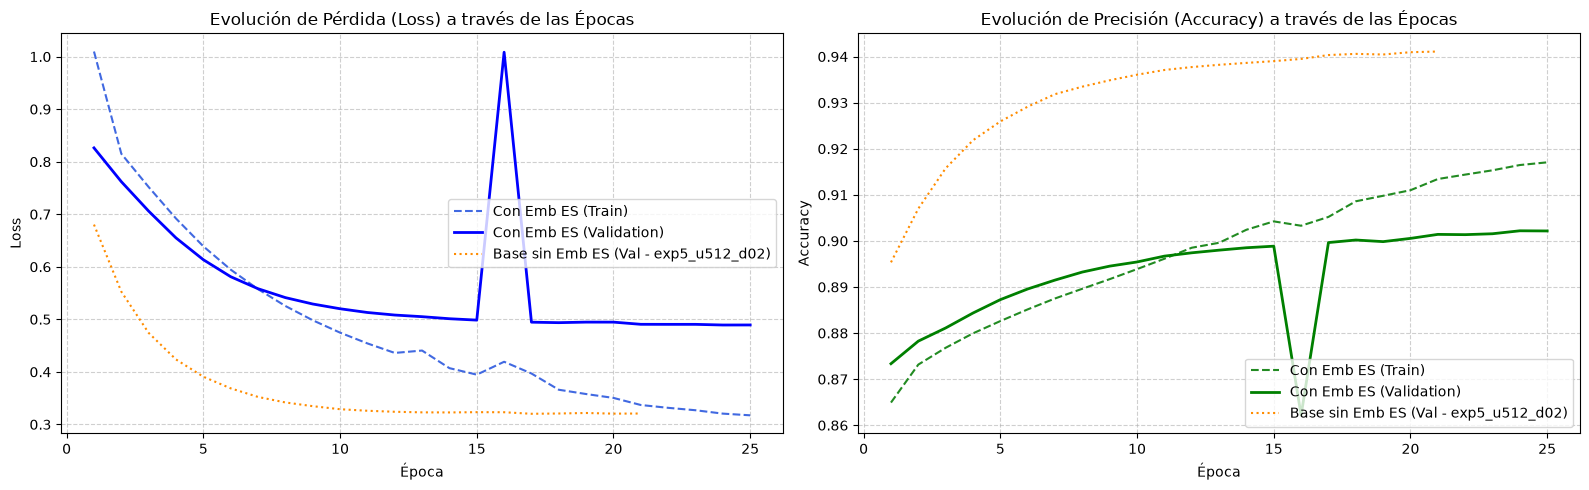

In [24]:
# Cargamos el historial del modelo base ganador para superponer la comparación
with open(os.path.join(MODELS_DIR, top_exp_name, 'history.json'), 'r') as f:
    base_hist = json.load(f)

# Se recarga el hist_es desde el archivo guardado
with open(history_es_path, 'r') as f:
        hist_es = json.load(f)

epochs_range = range(1, len(hist_es['loss']) + 1)
base_epochs  = range(1, len(base_hist['val_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Loss
axes[0].plot(epochs_range, hist_es['loss'], label='Con Emb ES (Train)', color='royalblue', linestyle='--')
axes[0].plot(epochs_range, hist_es['val_loss'], label='Con Emb ES (Validation)', color='blue', linewidth=2)
axes[0].plot(base_epochs, base_hist['val_loss'], label=f'Base sin Emb ES (Val - {top_exp_name})', color='darkorange', linestyle=':')
axes[0].set_title('Evolución de Pérdida (Loss) a través de las Épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico de Accuracy
axes[1].plot(epochs_range, hist_es['accuracy'], label='Con Emb ES (Train)', color='forestgreen', linestyle='--')
axes[1].plot(epochs_range, hist_es['val_accuracy'], label='Con Emb ES (Validation)', color='green', linewidth=2)
axes[1].plot(base_epochs, base_hist['val_accuracy'], label=f'Base sin Emb ES (Val - {top_exp_name})', color='darkorange', linestyle=':')
axes[1].set_title('Evolución de Precisión (Accuracy) a través de las Épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    num_words_inputs, EMBED_DIM, embedding_matrix_en, max_input_len, top_n_units, dropout_rate=top_dropout
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, top_n_units, enc_states, dropout_rate=top_dropout, embedding_matrix_dec=embedding_matrix_es
)

# Construir modelos de inferencia
inf_enc_es = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, top_n_units)
inf_dec_es = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, top_n_units)
print("\n" + "="*80)
print(f"EVALUACIÓN CUALITATIVA: MODELO CON EMBEDDINGS EN ESPAÑOL ({exp_es_name})")
print("="*80)
print("\n--- [5 Ejemplos del Dataset de Test (Mismos de la Fase 3)] ---")
for i in range(5):
    pred_es_greedy = translate_sentence_greedy(sample_seqs[i], inf_enc_es, inf_dec_es)
    pred_es_beam   = translate_sentence_beam_search(sample_seqs[i], inf_enc_es, inf_dec_es, beam_width=3)
    
    print(f"[{i+1}] EN:            {sample_en[i]}")
    print(f"    ES (Real):      {sample_es_real[i]}")
    print(f"    ES (Greedy):    {pred_es_greedy}")
    print(f"    ES (Beam k=3):  {pred_es_beam}\n")
print("--- [5 Frases Nuevas No Vistas (Mismas de la Fase 3)] ---")
for i, s in enumerate(unseen_phrases):
    pred_new_greedy = translate_custom_text(s, inf_enc_es, inf_dec_es, strategy='greedy')
    pred_new_beam   = translate_custom_text(s, inf_enc_es, inf_dec_es, strategy='beam', beam_width=3)
    print(f"[{i+1}] EN:            {s}")
    print(f"    ES (Greedy):   {pred_new_greedy}")
    print(f"    ES (Beam k=3): {pred_new_beam}\n")


EVALUACIÓN CUALITATIVA: MODELO CON EMBEDDINGS EN ESPAÑOL (top_with_spanish_emb_exp5_u512_d02)

--- [5 Ejemplos del Dataset de Test (Mismos de la Fase 3)] ---
